# 🧪 MolE SMILES Tokenization Example

This notebook demonstrates how MolE tokenizes SMILES molecules using atom environments instead of character-level tokenization.

## Key Concepts:
- **Atom Environments**: Each atom is represented by its local chemical environment using Morgan fingerprints
- **Radius**: Controls the size of the environment (0 = just the atom, 1 = atom + neighbors, etc.)
- **Vocabulary**: Pre-trained dictionary mapping environment hashes to token IDs

In [3]:
# Import required libraries
import sys
import os
sys.path.append('../')  # Add project root to path

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import torch
from IPython.display import display, Markdown

# Import MolE components
from mole.data.datasets import getAtomEnvironments, open_dictionary

print("✅ All imports successful!")

✅ All imports successful!


## Step 1: Load the Pre-trained Vocabulary

MolE uses a pre-trained vocabulary that maps Morgan fingerprint hashes to token IDs.

In [4]:
# Load the MolE vocabulary
vocab_path = "../mole/data/vocabularies/vocabulary_207atomenvs_radius0_ZINC_guacamole.pkl"
dictionary = open_dictionary(vocab_path)

print(f"📚 Vocabulary loaded successfully!")
print(f"   • Vocabulary size: {len(dictionary)}")
print(f"   • Special tokens: {[k for k in dictionary.keys() if k in ['PAD', 'MASK', 'UNK', 'CLS']]}")
print(f"   • Sample token mappings:")

# Show some example mappings (first 5 non-special tokens)
sample_tokens = {k: v for k, v in list(dictionary.items())[:5] if isinstance(k, int)}
for hash_val, token_id in sample_tokens.items():
    print(f"     - Environment hash {hash_val} → Token ID {token_id}")

📚 Vocabulary loaded successfully!
   • Vocabulary size: 211
   • Special tokens: ['PAD', 'MASK', 'UNK', 'CLS']
   • Sample token mappings:
     - Environment hash 3387315712 → Token ID 1
     - Environment hash 2245273601 → Token ID 2
     - Environment hash 984188929 → Token ID 3
     - Environment hash 1016845826 → Token ID 4
     - Environment hash 1073491469 → Token ID 5


## Step 2: Define Our Example Molecule

Let's use **caffeine** as our example - it's a well-known molecule with interesting chemical environments.

🧪 Example Molecule: Caffeine
   • SMILES: CN1C=NC2=C1C(=O)N(C(=O)N2C)C
   • Molecular formula: C8H10N4O2
   • Number of atoms: 14
   • Number of bonds: 15


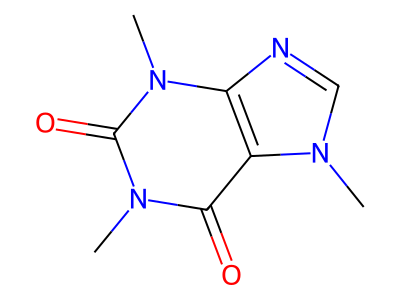

In [5]:
# Example molecule: Caffeine
smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"
mol = Chem.MolFromSmiles(smiles)

print(f"🧪 Example Molecule: Caffeine")
print(f"   • SMILES: {smiles}")
print(f"   • Molecular formula: {Chem.rdMolDescriptors.CalcMolFormula(mol)}")
print(f"   • Number of atoms: {mol.GetNumAtoms()}")
print(f"   • Number of bonds: {mol.GetNumBonds()}")

# Display the molecule structure
img = Draw.MolToImage(mol, size=(400, 300))
display(img)

## Step 3: Analyze Individual Atoms

Let's examine each atom in the molecule and understand its local environment.

In [6]:
print("🔍 Atom Analysis:")
print("="*60)

for i, atom in enumerate(mol.GetAtoms()):
    symbol = atom.GetSymbol()
    degree = atom.GetDegree()
    hybridization = atom.GetHybridization()
    formal_charge = atom.GetFormalCharge()
    
    # Get neighbors
    neighbors = [mol.GetAtomWithIdx(n.GetIdx()).GetSymbol() for n in atom.GetNeighbors()]
    
    print(f"Atom {i:2d}: {symbol:2s} | Degree: {degree} | Neighbors: {neighbors} | Hybridization: {hybridization}")

🔍 Atom Analysis:
Atom  0: C  | Degree: 1 | Neighbors: ['N'] | Hybridization: SP3
Atom  1: N  | Degree: 3 | Neighbors: ['C', 'C', 'C'] | Hybridization: SP2
Atom  2: C  | Degree: 2 | Neighbors: ['N', 'N'] | Hybridization: SP2
Atom  3: N  | Degree: 2 | Neighbors: ['C', 'C'] | Hybridization: SP2
Atom  4: C  | Degree: 3 | Neighbors: ['N', 'C', 'N'] | Hybridization: SP2
Atom  5: C  | Degree: 3 | Neighbors: ['C', 'C', 'N'] | Hybridization: SP2
Atom  6: C  | Degree: 3 | Neighbors: ['C', 'O', 'N'] | Hybridization: SP2
Atom  7: O  | Degree: 1 | Neighbors: ['C'] | Hybridization: SP2
Atom  8: N  | Degree: 3 | Neighbors: ['C', 'C', 'C'] | Hybridization: SP2
Atom  9: C  | Degree: 3 | Neighbors: ['N', 'O', 'N'] | Hybridization: SP2
Atom 10: O  | Degree: 1 | Neighbors: ['C'] | Hybridization: SP2
Atom 11: N  | Degree: 3 | Neighbors: ['C', 'C', 'C'] | Hybridization: SP2
Atom 12: C  | Degree: 1 | Neighbors: ['N'] | Hybridization: SP3
Atom 13: C  | Degree: 1 | Neighbors: ['N'] | Hybridization: SP3


## Step 4: Generate Morgan Fingerprints

Now let's see how MolE generates Morgan fingerprints for each atom environment.

In [7]:
def analyze_morgan_fingerprints(mol, radius=0):
    """Analyze Morgan fingerprints for each atom in the molecule."""
    
    info = {}
    # Generate Morgan fingerprints with detailed info
    fp = AllChem.GetMorganFingerprint(
        mol, 
        radius, 
        bitInfo=info, 
        includeRedundantEnvironments=True,
        useFeatures=False  # Using standard atom environments
    )
    
    print(f"🔬 Morgan Fingerprint Analysis (radius={radius}):")
    print("="*80)
    
    # Create mapping from atom index to environment hash
    atom_to_env = {}
    
    for env_hash, atom_info_list in info.items():
        for atom_idx, radius_level in atom_info_list:
            if radius_level == radius:  # Only consider the specified radius
                atom_to_env[atom_idx] = env_hash
    
    # Display results sorted by atom index
    for atom_idx in sorted(atom_to_env.keys()):
        env_hash = atom_to_env[atom_idx]
        atom = mol.GetAtomWithIdx(atom_idx)
        symbol = atom.GetSymbol()
        
        print(f"Atom {atom_idx:2d} ({symbol:2s}): Environment hash = {env_hash:>12d}")
    
    return atom_to_env

# Analyze with radius 0 (just the atom itself)
atom_envs = analyze_morgan_fingerprints(mol, radius=0)

🔬 Morgan Fingerprint Analysis (radius=0):
Atom  0 (C ): Environment hash =   2246728737
Atom  1 (N ): Environment hash =   2092489639
Atom  2 (C ): Environment hash =   3218693969
Atom  3 (N ): Environment hash =   2041434490
Atom  4 (C ): Environment hash =   3217380708
Atom  5 (C ): Environment hash =   3217380708
Atom  6 (C ): Environment hash =   3217380708
Atom  7 (O ): Environment hash =    864942730
Atom  8 (N ): Environment hash =   2092489639
Atom  9 (C ): Environment hash =   3217380708
Atom 10 (O ): Environment hash =    864942730
Atom 11 (N ): Environment hash =   2092489639
Atom 12 (C ): Environment hash =   2246728737
Atom 13 (C ): Environment hash =   2246728737


[12:42:08] DEPRECATION WARNING: please use MorganGenerator


## Step 5: Convert to Tokens using MolE Vocabulary

Now let's use the MolE tokenization function to convert our molecule to tokens.

In [8]:
# Use MolE's tokenization function
radius = 0  # Same as vocabulary
useFeatures = False  # Standard atom environments

tokens = getAtomEnvironments(mol, dictionary, radius, useFeatures)

print(f"🎯 MolE Tokenization Results:")
print("="*80)
print(f"   • Input SMILES: {smiles}")
print(f"   • Number of atoms: {mol.GetNumAtoms()}")
print(f"   • Number of tokens: {len(tokens)}")
print(f"   • Token sequence: {tokens}")
print()

# Detailed atom-by-atom breakdown
print("📋 Detailed Tokenization Breakdown:")
print("-"*80)

for i, (atom, token_id) in enumerate(zip(mol.GetAtoms(), tokens)):
    symbol = atom.GetSymbol()
    
    # Find the environment hash for this atom
    env_hash = atom_envs.get(i, "Unknown")
    
    # Check if token is in vocabulary or UNK
    is_known = env_hash in dictionary if env_hash != "Unknown" else False
    token_type = "Known" if is_known else "Unknown (UNK)"
    
    print(f"Atom {i:2d}: {symbol:2s} | Env Hash: {env_hash:>12} | Token ID: {token_id:>3d} | Status: {token_type}")

# Show special tokens
print()
print("🔧 Special Tokens in Vocabulary:")
special_tokens = {k: v for k, v in dictionary.items() if k in ['PAD', 'MASK', 'UNK', 'CLS']}
for token_name, token_id in special_tokens.items():
    print(f"   • {token_name}: {token_id}")

🎯 MolE Tokenization Results:
   • Input SMILES: CN1C=NC2=C1C(=O)N(C(=O)N2C)C
   • Number of atoms: 14
   • Number of tokens: 14
   • Token sequence: [13, 180, 144, 159, 150, 150, 150, 54, 180, 150, 54, 180, 13, 13]

📋 Detailed Tokenization Breakdown:
--------------------------------------------------------------------------------
Atom  0: C  | Env Hash:   2246728737 | Token ID:  13 | Status: Known
Atom  1: N  | Env Hash:   2092489639 | Token ID: 180 | Status: Known
Atom  2: C  | Env Hash:   3218693969 | Token ID: 144 | Status: Known
Atom  3: N  | Env Hash:   2041434490 | Token ID: 159 | Status: Known
Atom  4: C  | Env Hash:   3217380708 | Token ID: 150 | Status: Known
Atom  5: C  | Env Hash:   3217380708 | Token ID: 150 | Status: Known
Atom  6: C  | Env Hash:   3217380708 | Token ID: 150 | Status: Known
Atom  7: O  | Env Hash:    864942730 | Token ID:  54 | Status: Known
Atom  8: N  | Env Hash:   2092489639 | Token ID: 180 | Status: Known
Atom  9: C  | Env Hash:   3217380708 | Token ID

[12:42:19] DEPRECATION WARNING: please use MorganGenerator


## Step 6: Create PyTorch Tensor for Model Input

Finally, let's convert our tokens to a PyTorch tensor ready for model input.

In [9]:
# Convert to PyTorch tensor
token_tensor = torch.tensor(tokens, dtype=torch.long)

print(f"🚀 Model-Ready Output:")
print("="*50)
print(f"   • Token tensor shape: {token_tensor.shape}")
print(f"   • Token tensor dtype: {token_tensor.dtype}")
print(f"   • Token tensor: {token_tensor}")
print()
print(f"   • Min token ID: {token_tensor.min().item()}")
print(f"   • Max token ID: {token_tensor.max().item()}")
print(f"   • Vocabulary size: {len(dictionary)}")

# Verify all tokens are within vocabulary range
max_vocab_id = max(dictionary.values())
all_valid = (token_tensor <= max_vocab_id).all()
print(f"   • All tokens valid: {all_valid} ✅" if all_valid else f"   • All tokens valid: {all_valid} ❌")

🚀 Model-Ready Output:
   • Token tensor shape: torch.Size([14])
   • Token tensor dtype: torch.int64
   • Token tensor: tensor([ 13, 180, 144, 159, 150, 150, 150,  54, 180, 150,  54, 180,  13,  13])

   • Min token ID: 13
   • Max token ID: 180
   • Vocabulary size: 211
   • All tokens valid: True ✅


## Step 7: Compare with Different Radii

Let's see how the tokenization changes with different environment radii.

In [10]:
def compare_radii(mol, dictionary, max_radius=2):
    """Compare tokenization results across different radii."""
    
    print(f"🔍 Radius Comparison for Caffeine:")
    print("="*60)
    
    for radius in range(max_radius + 1):
        # Generate Morgan fingerprints for this radius
        info = {}
        AllChem.GetMorganFingerprint(
            mol, radius, bitInfo=info, 
            includeRedundantEnvironments=True, useFeatures=False
        )
        
        # Count unique environments at this radius
        unique_envs = set()
        for env_hash, atom_info_list in info.items():
            for atom_idx, radius_level in atom_info_list:
                if radius_level == radius:
                    unique_envs.add(env_hash)
        
        print(f"Radius {radius}: {len(unique_envs):2d} unique environments | ", end="")
        
        # Check how many are in our vocabulary
        known_envs = sum(1 for env in unique_envs if env in dictionary)
        unknown_envs = len(unique_envs) - known_envs
        
        print(f"{known_envs:2d} known, {unknown_envs:2d} unknown (→UNK)")

# Compare different radii (note: our vocabulary is trained on radius 0)
compare_radii(mol, dictionary, max_radius=2)

🔍 Radius Comparison for Caffeine:
Radius 0:  6 unique environments |  6 known,  0 unknown (→UNK)
Radius 1: 10 unique environments |  0 known, 10 unknown (→UNK)
Radius 2: 13 unique environments |  0 known, 13 unknown (→UNK)


[12:42:48] DEPRECATION WARNING: please use MorganGenerator
[12:42:48] DEPRECATION WARNING: please use MorganGenerator
[12:42:48] DEPRECATION WARNING: please use MorganGenerator


## 📝 Summary

This example demonstrated the complete MolE tokenization pipeline:

1. **Input**: SMILES string representing a molecule
2. **RDKit Processing**: Convert SMILES to molecular object
3. **Morgan Fingerprints**: Generate environment hashes for each atom
4. **Vocabulary Lookup**: Map environment hashes to token IDs
5. **Fallback**: Unknown environments get UNK token
6. **Output**: Sequence of token IDs ready for transformer input

### Key Advantages of This Approach:
- **Chemically Meaningful**: Each token represents a real chemical environment
- **Variable Length**: Naturally handles molecules of different sizes
- **Robust**: Unknown environments gracefully fallback to UNK token
- **Scalable**: Pre-trained vocabulary works across diverse chemical spaces